In [16]:
pip install tabulate


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [20]:
import pandas as pd

dataset = pd.read_csv("Social_Network_Ads.csv")

from tabulate import tabulate
print(tabulate(dataset.head(), headers='keys', tablefmt='grid'))


+----+-----------+----------+-------+-------------------+-------------+
|    |   User ID | Gender   |   Age |   EstimatedSalary |   Purchased |
+====+===========+==========+=======+===================+=============+
|  0 |  15624510 | Male     |    19 |             19000 |           0 |
+----+-----------+----------+-------+-------------------+-------------+
|  1 |  15810944 | Male     |    35 |             20000 |           0 |
+----+-----------+----------+-------+-------------------+-------------+
|  2 |  15668575 | Female   |    26 |             43000 |           0 |
+----+-----------+----------+-------+-------------------+-------------+
|  3 |  15603246 | Female   |    27 |             57000 |           0 |
+----+-----------+----------+-------+-------------------+-------------+
|  4 |  15804002 | Male     |    19 |             76000 |           0 |
+----+-----------+----------+-------+-------------------+-------------+


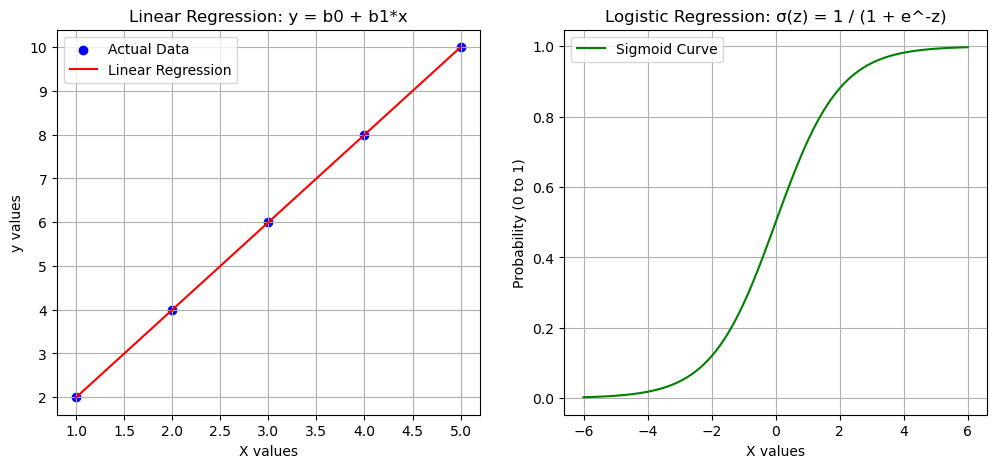

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

X_linear = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y_linear = np.array([2, 4, 6, 8, 10])  

linear_model = LinearRegression()
linear_model.fit(X_linear, y_linear)
y_pred_linear = linear_model.predict(X_linear)

X_logistic = np.linspace(-6, 6, 100)
y_logistic = sigmoid(X_logistic) 

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_linear, y_linear, color='blue', label="Actual Data")
plt.plot(X_linear, y_pred_linear, color='red', label="Linear Regression")
plt.title("Linear Regression: y = b0 + b1*x")
plt.xlabel("X values")
plt.ylabel("y values")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(X_logistic, y_logistic, color='green', label="Sigmoid Curve")
plt.title("Logistic Regression: σ(z) = 1 / (1 + e^-z)")
plt.xlabel("X values")
plt.ylabel("Probability (0 to 1)")
plt.legend()
plt.grid()

plt.show()


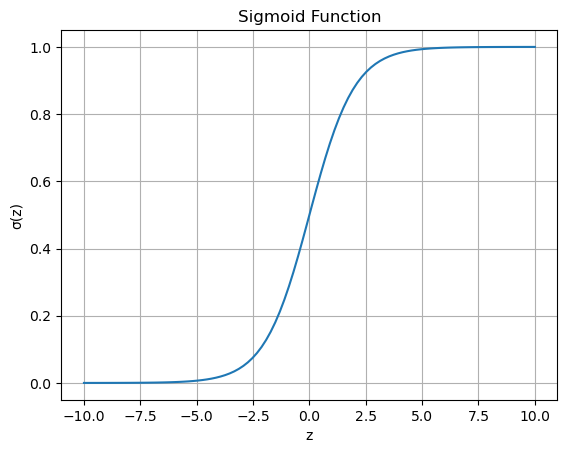

In [19]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-10, 10, 100)
plt.plot(z, sigmoid(z))
plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("σ(z)")
plt.grid()
plt.show()


In [24]:
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from tabulate import tabulate

warnings.simplefilter(action='ignore', category=FutureWarning)

dataset = pd.read_csv("Social_Network_Ads.csv")

print("\nDataset Preview:\n")
print(tabulate(dataset.head(), headers='keys', tablefmt='grid'))

X = dataset[['Age', 'EstimatedSalary']].values  
y = dataset['Purchased'].values  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

multi_logistic = LogisticRegression(solver='lbfgs')
multi_logistic.fit(X_train, y_train)

y_pred_multi = multi_logistic.predict(X_test)
print("\nLogistic Regression Predictions:\n", y_pred_multi)

cm = confusion_matrix(y_test, y_pred_multi)
cm_df = pd.DataFrame(cm, index=["Actual 0", "Actual 1"], columns=["Predicted 0", "Predicted 1"])
print("\nConfusion Matrix:\n")
print(tabulate(cm_df, headers='keys', tablefmt='grid'))

report_df = pd.DataFrame(classification_report(y_test, y_pred_multi, output_dict=True)).transpose()
print("\nClassification Report:\n")
print(tabulate(report_df, headers='keys', tablefmt='grid'))



Dataset Preview:

+----+-----------+----------+-------+-------------------+-------------+
|    |   User ID | Gender   |   Age |   EstimatedSalary |   Purchased |
+====+===========+==========+=======+===================+=============+
|  0 |  15624510 | Male     |    19 |             19000 |           0 |
+----+-----------+----------+-------+-------------------+-------------+
|  1 |  15810944 | Male     |    35 |             20000 |           0 |
+----+-----------+----------+-------+-------------------+-------------+
|  2 |  15668575 | Female   |    26 |             43000 |           0 |
+----+-----------+----------+-------+-------------------+-------------+
|  3 |  15603246 | Female   |    27 |             57000 |           0 |
+----+-----------+----------+-------+-------------------+-------------+
|  4 |  15804002 | Male     |    19 |             76000 |           0 |
+----+-----------+----------+-------+-------------------+-------------+

Logistic Regression Predictions:
 [0 1 0 1 0

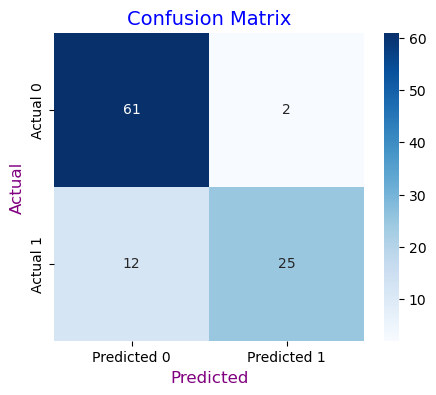

In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

warnings.simplefilter(action='ignore', category=FutureWarning)

dataset = pd.read_csv("Social_Network_Ads.csv")

X = dataset[['Age', 'EstimatedSalary']].values  
y = dataset['Purchased'].values  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

logistic_model = LogisticRegression(solver='lbfgs')
logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Predicted 0", "Predicted 1"], yticklabels=["Actual 0", "Actual 1"])
plt.xlabel("Predicted", fontsize=12, color="purple")
plt.ylabel("Actual", fontsize=12, color="purple")
plt.title("Confusion Matrix", fontsize=14, color="blue")
plt.show()
